In [1]:
%pip install pandas matplotlib seaborn numpy scipy

Note: you may need to restart the kernel to use updated packages.


# Analise Exploratória dos dados

## Elementos de dados estruturados

Dados em si podem vir de inumeras fontes como medicoes de sensores, eventos, imagens e videos. Muitos desses dados sao nao estruturados, como imagens que sao matrizes de ou valores escalares de pixeis que variam de 0-255 (em caso preto e branco) ou triplas de 3 escalares que variam cada um de 0 a 255. Textos sao outro exemplo de dado nao estruturado que possuem caracteres, palavras, frases e etc. Dito isso, normalmente é necessário transformar e esses dados em forma estruturada (linhas e colunas por exemplo) para podermos aplicar metodos estatisticos. Existem dois conjuntos basicos de tipos de dados:

- Numerico (ou Quantitativo):

  Os dados numericos sao dados que podem ser expressos em escalar numérica e podem ser divididos em 2 subcategorias que sao continuos e discretos:

  - Dados continuos podem assumir um conjunto infinito de valores reais (como comprimentos e dinheiro)
  - Dados discretos podem assumir um conjunto finito de valores inteiros (como contagens e idade)

- Categorico (ou Qualitativo):

  Os dados categorios sao dados que assumem classes ou categorias de uma instancia e podem ser divididos em 2 subcategorias:

  - Nominais sao categorias que assumem classes distintas sem hierarquia interna (como tipo de TV e Sexo)
  - Ordinais sao seguem a mesma logica das nominais mas as classes possuem uma ordem (como grau de escolaridade em que superior > medio > fundamental)

Ter uma nocao sobre tipos de dados é importante pois existem métricas estatisticas especificas para tipos distintos e formas melhores de se visualizar.
Além disso, existem otimizacoes na indexacao e estao presentes em software em funcoes como ENUM.
Importante sempre saber a entrada esperada de alguma funcao ou metodo pois se ele assumi apenas valores numericos, colocar um valor categorico sera um problema.

In [2]:
continuos = [1.0, 2.5, 3.3, 3.5, 4.8, 5.5]
discrete = [int(x) for x in continuos]

print("- Numerical values ")
print("Continuous values:", continuos)
print("Discrete values:", discrete)

nominal = ['apple', 'banana', 'orange', 'apple', 'orange', 'banana']
ordinal = ['low', 'medium', 'high', 'medium', 'low', 'high']

print("\n- Categorical values ")
print("Nominal values:", nominal)
print("Ordinal values:", ordinal)


- Numerical values 
Continuous values: [1.0, 2.5, 3.3, 3.5, 4.8, 5.5]
Discrete values: [1, 2, 3, 3, 4, 5]

- Categorical values 
Nominal values: ['apple', 'banana', 'orange', 'apple', 'orange', 'banana']
Ordinal values: ['low', 'medium', 'high', 'medium', 'low', 'high']


## Estimativas de Localizao nos dados (ou posicao)

Um passo basico ao explorar seus dados é verificar a tendencia central de uma variavel. Um ponto importante é lembrar do motivo de ser chamado de estimativa pois nao necessáriamente a media amostral (ou qualquer outra estatistica amostral) reflexe a media populacional (tambem conhecida como esperanca E[X]). Uma estimativa é um valor calculado a partir de uma amostra e é usado para aproximar um parametro (media populacional, variancia populacional e etc) desconhecido da populacao. Esse mesmo numero pode também ser chamado de metrica e signica a mesma coisa pois é uma matrica de uma amostra e demonstra algo em relacao a amostra.
(Estatisticos normalmente diferem N e n, sendo N em relacao a populacao e n a amostra, ou seja maisculos em um e minusculos em outro)

- Media:
A estimativa mais basica é media que consiste na soma de todos os valores e divisao pela quantidade de valores 

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

Uma grande desvantagem dela é ser fortemente influenciada por valores fora do comum (outliers), podendo ser levada muito para baixo ou muito para cima e nao mais representar o valor medio (tipico) daquela distribuicao pois a media se desloca em direcao a calda. (Nao é robusta)
Além disso, duas amostras totalmente diferentes podem ter medias iguais e portanto nao descreve muita coisa.

- Media "Cortada ou Aparada":
Essa variacao da media ordena os valores inicialmente e retira uma fracao *p* do inicio e fim dos valores ordenados, retirando os possiveis valores muito grandes e muito pequenos e dividindo pela contagem do restanto dos elementos nao retirados.

$$
\bar{x}_{p} = \frac{1}{n - 2k}
\sum_{i = k+1}^{n-k} x_{(i)},
\quad \text{com } k = \lfloor p n \rfloor
$$

Ela é mais robusta em relacao ao outliers porem existe perda de informacao

- Media Ponderada: 
  Essa variacao vale para quando cada elemento tem pesos (importancias) diferentes, multiplicando todos os valores pelos seus respectivos pesos e somando, em seguida divindo pela soma dos pesos.

  $$
  \bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}
  $$

  Existem dois cenários principais em que a media ponderada é muito util: 
  - Quando alguns valores sao menos confiaveis que outros (varia muito, pouca precisao e etc...) entao queremos dar mais peso para os valores confiaveis e menos peso para os nao confiaveis. Um exemplo disso pode ser palpites de valores de um Senior e Estagiário, podemos ponderar ambos mas dar mais peso para o Senior.
  - Os dados coletados nao representam igualmente (de forma justa) todos os grupos que desejamos estudar, ou seja, estamos enviesados de certa forma e portanto queremos dar mais peso para os grupos pouco representados nos dados para tornar justo o procedimento. Isso é muito comum em problemas de classificacao multiclasse em que os dados de treino estao desbalanceados, tendo muitos exemplos de uma classe e poucos de outra. Portanto nesses casos ponderar pode ajudar a balancear

- Mediana (ou Quartil 2 ou Quantil(0.5)):

Mediana é o ponto localizado no centro de valores ordenados (caso seja um total par, ela é a media dos 2 elementos centrais). Garante que 50% dos valores estao abaixo (menores que ela) e 50% acima dela (maiores que ela).

Sejam os valores ordenados
$$
x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}.
$$

A mediana é definida por
$$
\tilde{x} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & \text{se } n \text{ é ímpar}, \\[6pt]
\displaystyle \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}, & \text{se } n \text{ é par}.
\end{cases}
$$

A mediana depende apenas dos valores centrais do dado ordenado e pode ser muito robusta em casos com outliers. Por exemplo, se olharmos a media de salarios da rua da casa de bill gates teriamos um valor exorbintante levando a crer que todos ali na rua recebem muito bem já que a media é alta. Porém isso nao necessáriamente é verdade. Se pegarmos a mediana, nao importa o quao rico bill gates seja pois nao afetara o valor central ordenado.

- Mediana Ponderada:
Ela é o valor que divide a distribuição ponderada em duas partes, garantindo que pelo menos 50% do peso total esteja abaixo e pelo menos 50% acima. Valor que a soma acumulada dos pesos abaixo e acima sejam pelo menos a metade da soma total dos pesos. (Ordenada pelos valores e nao os pesos)

$$
\tilde{x}_w = x_{(k)}
\quad \text{tal que} \quad
\sum_{i=1}^{k} w_i \ge \frac{1}{2}\sum_{i=1}^{n} w_i
\quad \text{e} \quad
\sum_{i=k}^{n} w_i \ge \frac{1}{2}\sum_{i=1}^{n} w_i
$$

Assim como a mediana, ela também é robusta a outliers.Ela é especialmente útil quando observações se repetem com frequências diferentes ou quando algumas medições devem influenciar mais a posição central do que outras.

- Outliers ?

Um outlier é um valor que se encontra em uma região extrema da distribuição dos dados, isto é, muito distante da maior parte das observações segundo algum critério estatístico. Existem várias definições formais, normalmente baseadas em medidas de posição e dispersão, como quantis ou variabilidade.Um outlier não é necessariamente um erro. Ele pode representar um valor real e válido (como no exemplo do Bill Gates), mas também pode ser resultado de erro de medição, coleta, processamento ou preparação dos dados. Por esse motivo, outliers devem sempre ser identificados e investigados antes de serem removidos ou utilizados, pois valores extremos artificiais podem distorcer fortemente estimativas como a média.Em alguns problemas, especialmente na área de detecção de anomalias, os outliers não são ruído, mas sim o principal objeto de interesse, pois buscamos entender por que esses comportamentos raros ocorrem. Do ponto de vista de estimação, medidas robustas como a mediana e a média aparada são menos sensíveis a outliers. A média aparada pode ser vista como um compromisso entre a média e a mediana, pois reduz a influência de valores extremos mantendo mais informação dos dados centrais. Métodos mais sofisticados de detecção e tratamento de outliers existem, mas seu uso depende do tamanho do conjunto de dados, da dimensionalidade e das suposições do modelo adotado.

### Explicacao de Murder Rate (Taxa de homicídios)

O *murder rate* é uma **taxa padronizada** que mede a frequência de homicídios em uma população, permitindo comparar regiões com tamanhos populacionais diferentes.

Ele é definido como o número de homicídios ocorridos em um determinado período (geralmente um ano), dividido pela população da região, multiplicado por uma constante de escala.

A fórmula é:

$$
\text{Murder Rate}
=
\frac{H}{N} \times 100\,000
$$

onde:
- \( H \) é o número de homicídios no período (1 ano)
- \( N \) é a população total
- \( 100\,000 \) é um fator de escala para facilitar a interpretação

A interpretação é direta:
> Quantos homicídios ocorreriam por ano a cada 100 mil habitantes.

### Por que usar uma taxa

Usar apenas o número absoluto de homicídios não é adequado para comparação, pois regiões mais populosas tendem a ter mais ocorrências apenas por terem mais pessoas. A taxa ajusta esse efeito, permitindo comparações justas entre estados, cidades ou países.

### Relação com médias ponderadas

Como o murder rate é calculado a partir de contagens absolutas, a **taxa nacional correta** é obtida pela média ponderada das taxas regionais, usando a população como peso:

$$
\bar{r}
=
\frac{\sum_i r_i N_i}{\sum_i N_i}
=
\frac{\sum_i H_i}{\sum_i N_i} \times 100\,000
$$

Isso garante que a taxa final represente o risco médio enfrentado por um indivíduo escolhido aleatoriamente na população.


In [3]:
import pandas as pd
import numpy as np


df = pd.read_csv("data_statistics/state.csv")

print("Estatisticas sem outlier: \n")

# media 
sum = df["Population"].sum()
mean = sum / len(df)
print("Mean population:", mean)

# media aparada com p=0.1
ordered_pop = df["Population"].sort_values() # ordena 
k = max(int(0.1 * len(ordered_pop)), 1) # numero de elementos que vamos tirar de cada ponta
trimmed_mean = ordered_pop.iloc[k:-k].mean() 
print("Trimmed mean population:", trimmed_mean)

# mediana 
median = df["Population"].median()
print("Median population:", median)


# adicionando um outlier
df_outlier = pd.concat([df, pd.DataFrame([{"State": "New State", "Population": 100000000, "Murder rate": 10.0, "Abbreviation": "NS"}])], ignore_index=True)

print("\n")
print("Estatisticas com outlier: \n")

# plotando as mesmas estatisticas
mean_outlier = df_outlier["Population"].sum() / len(df_outlier)
print("Mean population:", mean_outlier)
trimmed_mean_outlier = df_outlier["Population"].sort_values().iloc[k:-k].mean()
print("Trimmed mean population:", trimmed_mean_outlier)
median_outlier = df_outlier["Population"].median()
print("Median population:", median_outlier)

print("\n")
print("Media ponderada e Mediana ponderada:\n")
# media e mediana ponderada

# Se queremos saber a media das taxas de assassinatos era apenas tirar a media de Muder rate (Qual é a taxa média se eu escolher um estado aleatoriamente?)
# Agora se queremos saber a taxa media de assassinatos do pais precisamos da media ponderada porque os estados não representam a mesma quantidade de pessoas, portanto suas taxas tem que ser ponderadas pela populacao total (Qual é a taxa média se eu escolher uma pessoa aleatoriamente no país?)

weighted_mean = (df["Population"] * df["Murder.Rate"]).sum() / df["Population"].sum()
print("Weighted mean murder rate:", weighted_mean)

# Calcular mediana ponderada
df_sorted = df.sort_values("Murder.Rate").reset_index(drop=True)
cumulative_weights = df_sorted["Population"].cumsum()
total_weight = df_sorted["Population"].sum()
weighted_median = df_sorted.loc[cumulative_weights >= total_weight / 2, "Murder.Rate"].iloc[0]
print("Weighted median murder rate:", weighted_median)


Estatisticas sem outlier: 

Mean population: 6162876.3
Trimmed mean population: 4783697.125
Median population: 4436369.5


Estatisticas com outlier: 

Mean population: 8002819.901960785
Trimmed mean population: 4979963.8292682925
Median population: 4533372.0


Media ponderada e Mediana ponderada:

Weighted mean murder rate: 4.445833981123393
Weighted median murder rate: 4.4


## Estimativas de Dispersao (Variacao)

Outras estimativas importantes sao as de dispersao pois elas medem o quao agrupado ou espalhado estao os dados. Variabilidade é um conceito central em estatistica e muitas vezes queremos medir ela, reduzir ela ou indentificar a fonte dela para entender os dados. A maioria das estimativas de dispersao sao baseadas nas diferencas ou desvios entre os valores e o alguma estimativa de posicao (como media). Por exemplos, se pegarmos os valores [1,4,4] a media é 3 e mediana é 4. Os desvios em relacao a media sao respectivamente -2, 1 e 1 e eles nos dizem o quao disperso estao os dados em relacoa ao valor central de posicao escolhido.Uma forma de medir essa dispersao é achar um valor tipico (medio) desses desvios, porém, a soma dos desvios é sempre igual a zero e portanto nao podemos fazer a media dos desvios (Exemplo anterior: -2 + 1 + 1 = 0). Uma forma de contornar esse problema é usando valores absolutos:

- Desvio Medio Absoluto: Consiste na soma dos desvios absolutos (sem sinal) dividido pelo total.

$$
\mathrm{MAD}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left| x_i - \bar{x} \right|
$$

Porem desvios maiores sao piores que desvios menores, devemos realmente dar o mesmo peso ? ai entra variancia!

- Variancia Amostral e Populacional: Consiste na soma dos desvios ao quadrado dividido pelo total de elementos (ou pelo (total - 1) caso seja uma amostra).

  $$
  \sigma^2
  =
  \frac{1}{n}
  \sum_{i=1}^{n}
  \left( x_i - \mu \right)^2
  $$

  Agora, valores maiores de desvio agora sao mais penalizados gerando um maior valor na media. Um problema disso é que agora a saimos da escala original e estamos na escala ao quadrado (antes o desvio era em metros, agora é em metros^2), tornando a interpretacao mais dificil.

   - Graus de liberdade ? dividir por n ou n-1: 

   (Isso é importante ? Na teoria sim mas na pratica quando a amostra é grande (muitos dados, ou seja, n vai para infinito) dividir por n ou n-1 tem diferenca insignificante)
   (Caso a amostra nao seja muito grande use n-1, caso seja gigante use qualquer um e caso seja a populacao use n)

   Graus de liberdade significam o numero de valores independentes que podem variar livremente dado algumas restricoes, por exemplo, se sabemos que a media de 3 valores é 10, se escolhermos 2 deles como 5 e 10, o ultimo valor nao tem liberdade de assumir qualquer valor, ele precisa ser 15 pois (15 + 10 + 5)/ 3 é 10. Logo, a restricao da media ser fixa (x1+x2+x3 = 10) tira um grau de liberdade do total (3) pois cria uma dependencia (contrario de independencia), portanto temos 2 graus de liberdade. Agora voltando a variancia, suponha que temos uma amostra de tamanho *n*, o primeiro passo para se calcular a variancia é calcular uma estimativa de posicao (normalmente a media amostral, vamos usar ela), antes de calcular a media todos os *n* valores sao independentes e podem variar livremente (por isso dividimos por n e nao por n-1 calculando a media). Assim que calculamos a media, nos fixamos um centro da distribuicao da amostra (que veio da propria amostra). Esse centro impoe uma dependencia em que os desvios da amostra tem que somar extamente 0 (que é um numero fixo). Entao agora sabemos que Soma((xi - media_amostral)) = 0, essa é nossa restricao em que n - 1 desvios tem liberdade mas o ultimo tem que ter um valor especifico para somar ser 0. Outra forma de ver isso é que quando fazemos a soma do quadrado dos desvios usando a media amostral, estamos minimizando os desvios (existe uma propriedade matematica disso: A soma dos quadrados dos desvios de um conjunto de dados é mínima quando calculada em relação à média desse próprio conjunto), porém ao minimizar esse desvio estamos subestimando (enviesados) as distancias reais (em relacao a media populacional) e portanto estamos subestimando a variancia real da populacao (a amostral será menor que a real), quando dividimos por n-1 estamos compensando essa subestimacao dividindo por um numero menor (gerando uma variancia um pouco maior).Quando temos a média real da população, não existe mais estimação de média. Como a média populacional é um valor fixo e externo (não depende dos dados que você está olhando no momento), ela não impõe uma restrição de dependência sobre os dados. Se você tem a população inteira, você tem a verdade absoluta sobre as distâncias. Não há viés a ser corrigido e nenhum grau de liberdade é 'gasto' para prever o centro, pois o centro já é conhecido. Portanto, você pode usar a informação total de todos os n dados de forma independente, dividindo pelo tamanho real do conjunto n.
   
- Desvio Padrao: Raiz da Variancia

$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$

O desvio padrao usa a raiz da variancia pois estamos falando da mesma unidade de medida original (pois raiz de altura^2 é altura) tornando a estimativa mais interpretavel.

- Estimativas robustas:

  Uma vez que usamos estimativas de posicao nao robustas para variancia e desvio padrao elas entao nao sao robustas contra outliers. Estimativas de dispersao robustas precisam utilizar estimativas de posicao robustas, logo:

  - Desvio Absoluto Mediano: Pegamos a mediana dos desvios absolutos (ordenados) em relacao a mediana dos dados (estimativa de posicao).
 
    $$
    \mathrm{MAD}
    =
    \operatorname{median}\!\left( \, \left| x_i - \operatorname{median}(x) \right| \, \right)
    $$

  - Desvio Padrao e Variancia aparada: Usa a media aparada para calcular os valores

- Estimativas baseadas em percentil/quantil (percentil (p(10%)) é um caso particular de quantil (q(0.1)), expresso em porcentagem):

Uma outra forma de estimar dispersao é baseada em dados ordenados (rankeados). A estimativa mais simples é o range (faixa dos valores) que mede a distancia do maximo e o minimo porem range é sensivel a outliers e nao é muito util como metrica geral. 
Um quantil(p) em que p é uma proporsao, signica que ordenando os valores p porcento dos valores sao menores ou iguais a quantil(p).
Para evitar outliers podemos olhar a faixa depois de retirar valores das pontas iniciais e/ou finais. Esse tipo de estimativa é baseada em diferencas entre percentils/quantis, por exemplo se quisermos saber o range entre q(0.2) e q(0.8) basta subtrair q(0.8) - q(0.2).
Uma medida comum de range é o interquartile range (IQR) que representa q(0.75) - q(0.25), ou seja, os 50% centrais dos dados
Calcular os quantils pode ser caro dependendo do tamanho do dataset pois é necessário ordenar os dados e por isso existem aproximacoes uteis para datasets gigantes.


In [4]:
# usando os mesmos dados anteriores
population = df["Population"]
outlier_population = df_outlier["Population"]

# verificando se a soma dos desvios é 0 mesmo
sum = 0
for val in population: # soma dos desvios
    sum += val - population.mean()

print("Soma dos desvios:", sum)
print("Esse valor é praticamente zero! É apenas erro de arredondamento de ponto flutuante.")
print()

print("Estimativas sem outliers:")

# desvio medio absoluto da populacao
sum = 0
for val in population: # soma dos desvios absolutos
    sum += abs(val - population.mean())
mean_deviation = sum / len(population) 
print("Desvio médio absoluto da população", mean_deviation)

# variancia
sum = 0
for val in population:
    sum += (val - population.mean())**2
variance = sum / len(population)
print("Variância da população:", variance)

# desvio padrao
print("Desvio padrão da população:", variance**0.5)

# desvio absoluto mediano (Robusto)
median_deviations = population.apply(lambda x: abs(x - population.median()))
median_of_deviations = median_deviations.median()
print("Desvio absoluto mediano da população:", median_of_deviations)

pop_range = population.max() - population.min()
print("Range da população:", pop_range)

iqr = population.quantile(0.75) - population.quantile(0.25)
print("Intervalo interquartil da população:", iqr)

print("\nEstimativas com outliers:")

# desvio medio absoluto da populacao
sum = 0
for val in outlier_population: # soma dos desvios absolutos
    sum += abs(val - outlier_population.mean())
mean_deviation = sum / len(outlier_population)
print("Desvio médio absoluto da população", mean_deviation)

# variancia
sum = 0
for val in outlier_population:
    sum += (val - outlier_population.mean())**2
variance = sum / len(outlier_population)
print("Variância da população:", variance)

# desvio padrao
print("Desvio padrão da população:", variance**0.5)

# desvio absoluto mediano (Robusto)
median_deviations = outlier_population.apply(lambda x: abs(x - outlier_population.median()))
median_of_deviations = median_deviations.median()
print("Desvio absoluto mediano da população:", median_of_deviations)

pop_range = outlier_population.max() - outlier_population.min()
print("Range da população:", pop_range)

iqr = outlier_population.quantile(0.75) - outlier_population.quantile(0.25)
print("Intervalo interquartil da população:", iqr)


print()

print("Experimento: viés da variância amostral e graus de liberdade\n")

# população (Population dos 8 estados)
population = df["Population"].values

# variância populacional verdadeira
var_pop = np.mean((population - population.mean())**2)

# parâmetros do experimento
# amostras pequenas tendem a ter mais viés, pois a média da amostra é uma estimativa ruim da média populacional, o que afeta a variância. 
# amostras maiores tendem a ter menos viés, pois a média da amostra é uma estimativa melhor da média populacional, o que afeta menos a variância. (Lembre-se, se a amostra é grande suficiente -> Foda-se)
n = 20   # tamanho da amostra
n_experiments = 1000000

vars_n = []
vars_n_minus_1 = []

for _ in range(n_experiments):
    sample = np.random.choice(population, size=n, replace=False)
    mean_sample = sample.mean()
    
    sq_dev = (sample - mean_sample)**2
    
    vars_n.append(sq_dev.sum() / n)
    vars_n_minus_1.append(sq_dev.sum() / (n - 1))

print("Variância populacional:", var_pop)
print("Média das variâncias com n:", np.mean(vars_n))
print("Média das variâncias com n-1:", np.mean(vars_n_minus_1))
print("Diferença variância media amostral(n-1) e populacional:", np.mean(vars_n_minus_1) - var_pop)
print("Diferença variância media amostral(n) e populacional:", np.mean(vars_n) - var_pop)

Soma dos desvios: -1.210719347000122e-08
Esse valor é praticamente zero! É apenas erro de arredondamento de ponto flutuante.

Estimativas sem outliers:
Desvio médio absoluto da população 4450933.356000001
Variância da população: 45960360825926.56
Desvio padrão da população: 6779407.114632265
Desvio absoluto mediano da população: 2596702.0
Range da população: 36690330
Intervalo interquartil da população: 4847308.0

Estimativas com outliers:
Desvio médio absoluto da população 7039736.281430221
Variância da população: 214328800200141.44
Desvio padrão da população: 14639972.684405576
Desvio absoluto mediano da população: 2707031.0
Range da população: 99436374
Intervalo interquartil da população: 5523114.5

Experimento: viés da variância amostral e graus de liberdade

Variância populacional: 45960360825926.56
Média das variâncias com n: 44525407786289.945
Média das variâncias com n-1: 46868850301357.84
Diferença variância media amostral(n-1) e populacional: 908489475431.2812
Diferença variâ

## Explorando a distribuicao dos dados (Numerico)

As metricas ate agora sao uteis para descrever em um unico valor a localizacao/posicao e a dispersao/variabilidade dos dados. É interessante tambem explorar a distribuicao dos dados:

- Quantils e Boxplots:

  Quantis sao muito uteis para sumarizar a distribuicao dos dados. Normalmente, é calculado os quantis [0.25, 0.5, 0.75] e [0.1, 0.2 ... 0.9]. Os quantis sao especialmente importantes para se estudar a cauda da distribuicao, que sao as regioes onde os valores sao extremos ou raros na distribuicao (longe do centro(media e mediana)). A cauda esquerda, sao os valores raros mais baixos e proximos do minimo e a cauda direita tem valores raros mais altos mais proximos do maximo. Exemplo: Se o quantil 0.95 da variavel salario tem valor 10000, significa que apenas 5% dos funcionarios ganham mais que esse valor e fazem parte da cauda. Uma cauda é pesada quando a probabilidade/frequencia dos valores mais extremos cai mais devagar quando nos afastamos do centro, ou seja, os eventos extremos sao mais frequentes do que o normal. (Na distribuicao normal as caudas nao sao pesadas pois as probabilidades delas sao baixas (caem rapido) e portanto sao bem raras).

  Boxplot é uma visualizacao muito importante que é divida em partes:
  - A linhas dentro da caixa representa a mediana dos dados 
  - A parte superior da caixa representa o quantil 0.75 e a parte inferior da caixa representa o quantil 0.25 (ou seja, a caixa representa a distribuicao dos 50% centrais dos dados)
  - O bigode superior é a faixa que representa até onde queremos ir na cauda normalmente é implementado como sendo o maior valor observado nos dados que esta no intervalo (Quantil(0.75) <= x <= Quantil(0.75) + 1.5xIQR) (IQR = Q(0.75) - Q(0.25)), já o inferior normalmente é o menor valor dentro do intervalo (Quantil(0.25) <= x <= Quantil(0.25) - 1.5xIQR). 
  - Os pontos que estao além dos bigodes normalmente sao considerados outliers pois fogem muito da distribuicao dos dados.



0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

Intervalo interquartil (IQR): 3.125


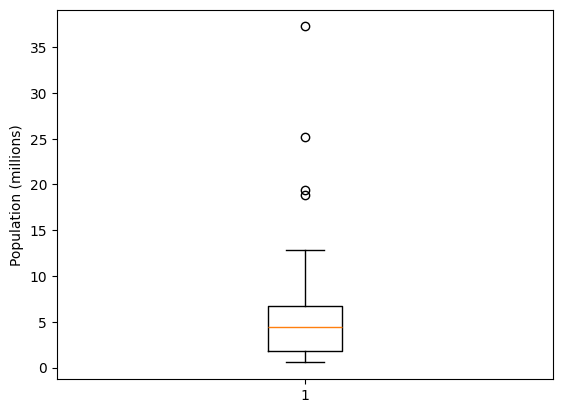

In [5]:
import matplotlib.pyplot as plt

# alguns quantis do murder rate
print(df["Murder.Rate"].quantile([0.05,0.25, 0.5, 0.75, 0.95]))
print()
# intervalo interquartil (IQR)
IQR = df["Murder.Rate"].quantile(0.75) - df["Murder.Rate"].quantile(0.25)
print("Intervalo interquartil (IQR):", IQR)


# boxplot da populacao em milhoes 
plt.boxplot(df["Population"]/1e6)
plt.ylabel("Population (millions)")
plt.show()

- Tabelas de frequencia e Histograma:

  A tabela de frequecia para uma variavel numérica divide os valores em um numero de intervalos igualmente espacados decidido por voce e conta quantos valores cada intervalo tem. Todo tipo de informacao dada pelas tabelas de frequencia é importante (inclusive se algum bin estiver vazio). Pode-se decidir o numero de Bins experimentalmente pois muitos Bins podem esconder informacoes importantes enquanto poucos Bins tornam as informacoes muito granulares tornando dificil a interpretacao ou identificacao de padroes. (Bins = caixas = intervalos). Tanto tabelas de frequencia como quartis trabalham com Bins (intervalos), porem enquanto quartis tem o tamanho do Bin variavel (a diferenca entre o quartil 0.25 e o 0.50 nao necessáriamente é igual as outras) e a quantidade de elementos por Bin fixa (cada bin tem 25% dos dados) a tabela tem o tamanho dos bins fixos (dividir 10 em 5 bins, cada bin tera tamanho 2) e a quantidade de elementos por bin variavel.

  Histograma é uma maneira de se visualizar tabelas de freqeuncia com os Bins no eixo x e a contagem no eixo y. Em geral histogramas seguem as seguintes regras:
  - Bins vazios sao incluidos no grafico
  - Bins tem que ter tamanhos iguais
  - O numero de bins depende do usuário
  - As barras sao contiguas (sem espaco em branco entre elas) a nao ser que tenha bins vazios

Geralmente para Assimetria da distribuicao e os valores extremos (outliers) nao sao usadas metricas diretas numéricas e sim plotados graficos como boxplot e histogramas pois permitem ver imediatamente essas coisas e nao sao instaveis e dificeis de interpretar como medidas numéricas.





Bin
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
dtype: int64

Bin
(526935.67, 4232659.0]      [AK, AR, CT, DE, HI, ID, IA, KS, ME, MS, MT, N...
(4232659.0, 7901692.0]      [AL, AZ, CO, IN, KY, LA, MD, MA, MN, MO, SC, T...
(7901692.0, 11570725.0]                              [GA, MI, NJ, NC, OH, VA]
(11570725.0, 15239758.0]                                             [IL, PA]
(15239758.0, 18908791.0]                                                 [FL]
(18908791.0, 22577824.0]                                                 [NY]
(22577824.0, 26246857.0]                                                 [TX]
(26246857.0, 29915890.0]                                                   []
(29915890.0, 33584923.0]                    

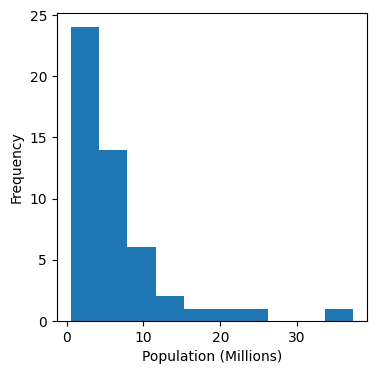

In [6]:
copy_df = df.copy()

copy_df["Bin"]= pd.cut(df["Population"], 10) # retorna os valores substituidos pelos seus respectivos intervalos (bins) (no caso eles viraram uma coluna de categoria)
bin_states =  copy_df.groupby("Bin", observed=False) # cria um agrupamento dos dados baseado nos bins

print(bin_states.size()) # mostra o tamanho de cada grupo
print()
print(bin_states["Abbreviation"].apply(list)) # mostra as abreviações dos estados em cada grupo

print()

# histogram
plt.figure(figsize=(4,4))
plt.hist(df["Population"]/1e6)
plt.xlabel("Population (Millions)")
plt.ylabel("Frequency")
plt.show()


- Plots de densidade e estimativas

Parecido com histogramas, um plot de densidade mostra a distribuicao através de uma linha continua (Pode ser visto como um histograma suavizado) ao invés de intervalos (Bins). Isso é computado por algo chamado estimacao de densidade por kernel (KDE - Kernel Density Estimate).que é uma forma de estimar a distribuicao continua sem assumir nenhuma modelo existente como o Normal.

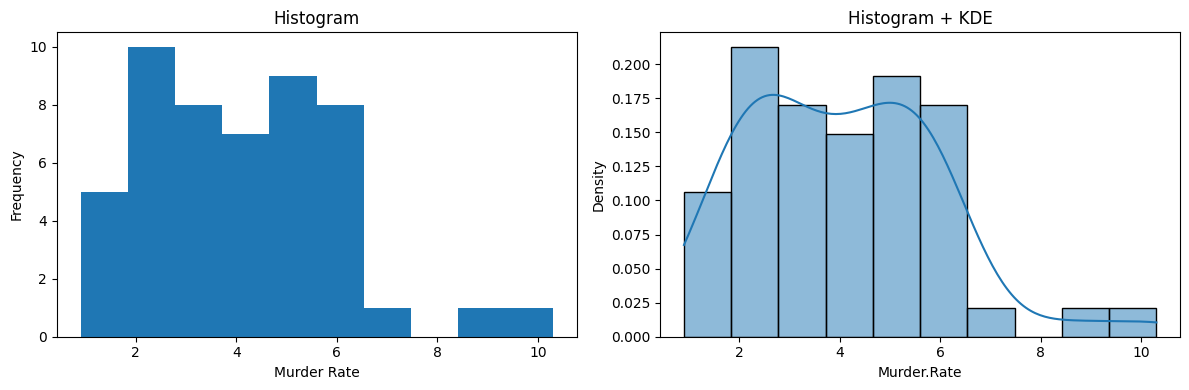

In [7]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# histograma de contagem
# Ideal para quando queremos visualizar a frequência absoluta dos dados
ax1.hist(df["Murder.Rate"], bins=10, density=False)
ax1.set_xlabel("Murder Rate")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram")

# histograma com Density Kernel
# Ideal para quando queremos uma estimativa suave da densidade ou comparar distribuições
sns.histplot(df["Murder.Rate"], kde=True, bins=10, stat="density", ax=ax2)
ax2.set_title("Histogram + KDE")

plt.tight_layout()
plt.show()

## Explorando dados binários e categoricos

Para dados categoricos simples proporcoes e porcentagens sao suficientes para entender os dados. Anteriormente quando Intervalamos os valores de variaveis continuas como populacao, basicamente transformamos elas em categoricas e isso é muito comum pois reduz o espaco e o custo em datasets muito grandes. 

Moda é outra métrica comum nesse tipo de variavel uma vez que ela mostra a frequencia mais comum (a classe/valor que mais aparece) de alguma variavel e pode ser util em alguns casos.


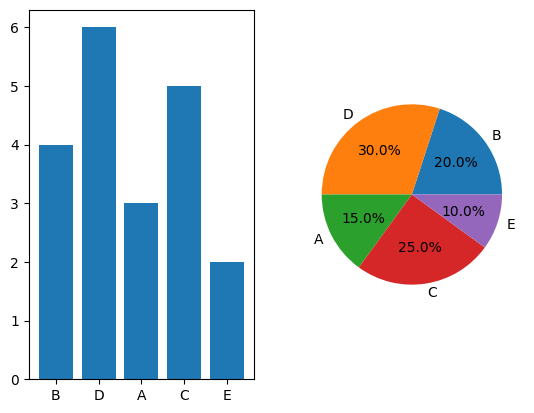

Moda:
  categoria
0         D


In [8]:
df_cat = pd.read_csv("data_statistics/categorical.csv")

# retorna a figura e os eixos (se fosse (1,4) retornaria fig, 4 eixos em formato de linha) (se fosse (2,2) retornaria fig, 4 eixos em formato de matriz)
# fig representa a figura que contém todos os eixos e cada eixo representa um gráfico individual
fig, (ax1, ax2) = plt.subplots(1, 2) 

# grafico de barras
ax1.bar(df_cat['categoria'].value_counts(sort=False).index, df_cat['categoria'].value_counts(sort=False))

# grafico de pizza(pie)
ax2.pie(df_cat['categoria'].value_counts(sort=False), labels=df_cat['categoria'].value_counts(sort=False).index, autopct='%1.1f%%')

plt.show()

print("Moda:")
print(df_cat.mode())

- Probabilidade (Resumo do Basico):

**Probabilidade clássica**
P(A) = |A| / |Ω|

Define a probabilidade de um evento A como o número de casos favoráveis dividido pelo número total de casos possíveis.

---

**Probabilidade complementar**
P(Aᶜ) = 1 − P(A)

A probabilidade de A não ocorrer é 1 menos a probabilidade de A ocorrer.

---

**Regra da soma (eventos quaisquer)**
P(A ∪ B) = P(A) + P(B) − P(A ∩ B)

Corrige a contagem dupla quando A e B podem ocorrer juntos.

---

**Regra da soma para eventos mutuamente exclusivos**
P(A ∪ B) = P(A) + P(B)

Se A e B não podem ocorrer simultaneamente, não existe interseção.

---

**Probabilidade condicional**
P(A | B) = P(A ∩ B) / P(B)

Probabilidade de A ocorrer dado que B já ocorreu.

---

**Regra do produto**
P(A ∩ B) = P(A | B) · P(B)

Permite calcular a probabilidade conjunta usando probabilidade condicional.

---

**Eventos independentes**
P(A ∩ B) = P(A) · P(B)

Se A não afeta a ocorrência de B, a probabilidade conjunta é o produto das probabilidades.

---

**Regra de Bayes**
P(A | B) = [ P(B | A) · P(A) ] / P(B)

Explicação:
Permite inverter a condição, calculando a probabilidade de A dado B a partir da probabilidade de B dado A.


- Valor Esperado:

**Definição de valor esperado (variável aleatória discreta)**
E[X] = Σ x · P(X = x)

O valor esperado é a média ponderada dos valores possíveis da variável aleatória.



In [9]:
print("=" * 60)
print("DEMONSTRAÇÃO DE CONCEITOS DE PROBABILIDADE")
print("=" * 60)

# ============================================================================
# 1. PROBABILIDADE CLÁSSICA
# ============================================================================
print("\n1. PROBABILIDADE CLÁSSICA: P(A) = |A| / |Ω|")
print("-" * 60)
print("Exemplo: Lançar um dado justo (6 faces)")

omega = {1, 2, 3, 4, 5, 6}  # Espaço amostral
A = {2, 4, 6}  # Evento: número par

P_A = len(A) / len(omega)
print(f"Ω = {omega}")
print(f"A (número par) = {A}")
print(f"P(A) = {len(A)}/{len(omega)} = {P_A:.4f}")

# ============================================================================
# 2. PROBABILIDADE COMPLEMENTAR
# ============================================================================
print("\n\n2. PROBABILIDADE COMPLEMENTAR: P(Aᶜ) = 1 − P(A)")
print("-" * 60)

P_A_complementar = 1 - P_A
print(f"P(não sair número par) = 1 - P(A) = 1 - {P_A:.4f} = {P_A_complementar:.4f}")

# ============================================================================
# 3. REGRA DA SOMA (EVENTOS QUAISQUER)
# ============================================================================
print("\n\n3. REGRA DA SOMA: P(A ∪ B) = P(A) + P(B) − P(A ∩ B)")
print("-" * 60)
print("Exemplo: Baralho com 52 cartas")

# Total de cartas
total_cartas = 52

# Evento A: carta vermelha (copas ou ouros)
A_vermelho = 26
P_vermelho = A_vermelho / total_cartas

# Evento B: carta é um Rei
B_rei = 4
P_rei = B_rei / total_cartas

# Interseção: Rei vermelho (Rei de copas ou Rei de ouros)
A_e_B = 2
P_vermelho_e_rei = A_e_B / total_cartas

# Probabilidade de ser vermelho OU rei
P_vermelho_ou_rei = P_vermelho + P_rei - P_vermelho_e_rei

print(f"P(vermelho) = {A_vermelho}/{total_cartas} = {P_vermelho:.4f}")
print(f"P(rei) = {B_rei}/{total_cartas} = {P_rei:.4f}")
print(f"P(vermelho ∩ rei) = {A_e_B}/{total_cartas} = {P_vermelho_e_rei:.4f}")
print(f"P(vermelho ∪ rei) = {P_vermelho:.4f} + {P_rei:.4f} - {P_vermelho_e_rei:.4f} = {P_vermelho_ou_rei:.4f}")

# ============================================================================
# 4. REGRA DA SOMA PARA EVENTOS MUTUAMENTE EXCLUSIVOS
# ============================================================================
print("\n\n4. EVENTOS MUTUAMENTE EXCLUSIVOS: P(A ∪ B) = P(A) + P(B)")
print("-" * 60)
print("Exemplo: Lançar um dado - sair 2 OU sair 5 (não podem ocorrer juntos)")

A_dois = {2}
B_cinco = {5}
P_dois = len(A_dois) / len(omega)
P_cinco = len(B_cinco) / len(omega)
P_dois_ou_cinco = P_dois + P_cinco

print(f"P(sair 2) = {P_dois:.4f}")
print(f"P(sair 5) = {P_cinco:.4f}")
print(f"P(sair 2 ∪ sair 5) = {P_dois:.4f} + {P_cinco:.4f} = {P_dois_ou_cinco:.4f}")

# ============================================================================
# 5. PROBABILIDADE CONDICIONAL
# ============================================================================
print("\n\n5. PROBABILIDADE CONDICIONAL: P(A | B) = P(A ∩ B) / P(B)")
print("-" * 60)
print("Exemplo: Dado que tirei uma carta vermelha, qual a prob. de ser Rei?")

# P(Rei | Vermelho) = P(Rei ∩ Vermelho) / P(Vermelho)
P_rei_dado_vermelho = P_vermelho_e_rei / P_vermelho

print(f"P(Rei | Vermelho) = P(Rei ∩ Vermelho) / P(Vermelho)")
print(f"P(Rei | Vermelho) = {P_vermelho_e_rei:.4f} / {P_vermelho:.4f} = {P_rei_dado_vermelho:.4f}")

# ============================================================================
# 6. REGRA DO PRODUTO
# ============================================================================
print("\n\n6. REGRA DO PRODUTO: P(A ∩ B) = P(A | B) · P(B)")
print("-" * 60)
print("Exemplo: Verificando a regra do produto com o exemplo anterior")

P_intersecao_calculada = P_rei_dado_vermelho * P_vermelho
print(f"P(Rei ∩ Vermelho) = P(Rei | Vermelho) · P(Vermelho)")
print(f"P(Rei ∩ Vermelho) = {P_rei_dado_vermelho:.4f} · {P_vermelho:.4f} = {P_intersecao_calculada:.4f}")
print(f"Verificação: P(Rei ∩ Vermelho) direto = {P_vermelho_e_rei:.4f} ✓")

# ============================================================================
# 7. EVENTOS INDEPENDENTES
# ============================================================================
print("\n\n7. EVENTOS INDEPENDENTES: P(A ∩ B) = P(A) · P(B)")
print("-" * 60)
print("Exemplo: Lançar dois dados independentes")

# Probabilidade de sair 6 no primeiro dado
P_dado1_6 = 1/6
# Probabilidade de sair 6 no segundo dado
P_dado2_6 = 1/6
# Probabilidade de ambos serem 6
P_ambos_6 = P_dado1_6 * P_dado2_6

print(f"P(primeiro dado = 6) = {P_dado1_6:.4f}")
print(f"P(segundo dado = 6) = {P_dado2_6:.4f}")
print(f"P(ambos = 6) = {P_dado1_6:.4f} · {P_dado2_6:.4f} = {P_ambos_6:.4f}")

# ============================================================================
# 8. REGRA DE BAYES
# ============================================================================
print("\n\n8. REGRA DE BAYES: P(A | B) = [P(B | A) · P(A)] / P(B)")
print("-" * 60)
print("Exemplo: Teste de doença")
print("- 1% da população tem a doença (prevalência)")
print("- Teste detecta doença em 95% dos doentes (sensibilidade)")
print("- Teste dá falso positivo em 10% dos saudáveis (1 - especificidade)")
print("\nQuestão: Se teste deu positivo, qual prob. de ter doença?")

# P(Doença)
P_doenca = 0.01
P_saudavel = 0.99

# P(Positivo | Doença) - sensibilidade
P_pos_dado_doenca = 0.95

# P(Positivo | Saudável) - taxa de falso positivo
P_pos_dado_saudavel = 0.10

# P(Positivo) - Probabilidade total de teste positivo
P_positivo = P_pos_dado_doenca * P_doenca + P_pos_dado_saudavel * P_saudavel

# P(Doença | Positivo) - Teorema de Bayes
P_doenca_dado_pos = (P_pos_dado_doenca * P_doenca) / P_positivo

print(f"\nP(Doença) = {P_doenca:.4f}")
print(f"P(Pos | Doença) = {P_pos_dado_doenca:.4f}")
print(f"P(Pos | Saudável) = {P_pos_dado_saudavel:.4f}")
print(f"P(Positivo) = {P_positivo:.4f}")
print(f"\nP(Doença | Pos) = [{P_pos_dado_doenca:.4f} · {P_doenca:.4f}] / {P_positivo:.4f}")
print(f"P(Doença | Pos) = {P_doenca_dado_pos:.4f} ou {P_doenca_dado_pos*100:.2f}%")
print("\nInterpretação: Mesmo com teste positivo, só ~8.7% de chance de ter doença!")
print("Isso ocorre porque a doença é rara (1%) e há falsos positivos.")

# ============================================================================
# 9. VALOR ESPERADO
# ============================================================================
print("\n\n9. VALOR ESPERADO: E[X] = Σ x · P(X = x)")
print("-" * 60)
print("Exemplo: Jogo de dados - você ganha o valor que sair no dado")

valores = [1, 2, 3, 4, 5, 6]
probabilidades = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

# Calculando valor esperado (não usar sum() pois foi redefinida em células anteriores)
E_X = np.sum([x * p for x, p in zip(valores, probabilidades)])

print("Valores possíveis: ", valores)
print("Probabilidades:    ", [f"{p:.4f}" for p in probabilidades])
print(f"\nE[X] = Σ x · P(X = x)")
print(f"E[X] = 1·(1/6) + 2·(1/6) + 3·(1/6) + 4·(1/6) + 5·(1/6) + 6·(1/6)")
print(f"E[X] = {E_X:.4f}")
print("\nInterpretação: Em média, você espera ganhar 3.5 por jogada")

print("\n" + "=" * 60)
print("Exemplo 2: Valor esperado de um jogo com prêmios diferentes")
print("=" * 60)

# Jogo: Lançar dado
# - Sair 6: ganha R$100
# - Sair 5: ganha R$50
# - Sair 1-4: perde R$10

valores_jogo = [100, 50, -10, -10, -10, -10]
prob_jogo = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

E_jogo = np.sum([v * p for v, p in zip(valores_jogo, prob_jogo)])

print(f"\nRegras:")
print(f"  Sair 6 (prob 1/6): ganha R$ 100")
print(f"  Sair 5 (prob 1/6): ganha R$ 50")
print(f"  Sair 1-4 (prob 4/6): perde R$ 10")
print(f"\nE[Ganho] = 100·(1/6) + 50·(1/6) + (-10)·(4/6)")
print(f"E[Ganho] = R$ {E_jogo:.2f}")

if E_jogo > 0:
    print(f"\nO jogo é favorável! Você espera ganhar R$ {E_jogo:.2f} por rodada em média.")
else:
    print(f"\nO jogo é desfavorável! Você espera perder R$ {abs(E_jogo):.2f} por rodada em média.")

print("\n" + "=" * 60)

DEMONSTRAÇÃO DE CONCEITOS DE PROBABILIDADE

1. PROBABILIDADE CLÁSSICA: P(A) = |A| / |Ω|
------------------------------------------------------------
Exemplo: Lançar um dado justo (6 faces)
Ω = {1, 2, 3, 4, 5, 6}
A (número par) = {2, 4, 6}
P(A) = 3/6 = 0.5000


2. PROBABILIDADE COMPLEMENTAR: P(Aᶜ) = 1 − P(A)
------------------------------------------------------------
P(não sair número par) = 1 - P(A) = 1 - 0.5000 = 0.5000


3. REGRA DA SOMA: P(A ∪ B) = P(A) + P(B) − P(A ∩ B)
------------------------------------------------------------
Exemplo: Baralho com 52 cartas
P(vermelho) = 26/52 = 0.5000
P(rei) = 4/52 = 0.0769
P(vermelho ∩ rei) = 2/52 = 0.0385
P(vermelho ∪ rei) = 0.5000 + 0.0769 - 0.0385 = 0.5385


4. EVENTOS MUTUAMENTE EXCLUSIVOS: P(A ∪ B) = P(A) + P(B)
------------------------------------------------------------
Exemplo: Lançar um dado - sair 2 OU sair 5 (não podem ocorrer juntos)
P(sair 2) = 0.1667
P(sair 5) = 0.1667
P(sair 2 ∪ sair 5) = 0.1667 + 0.1667 = 0.3333


5. PROBABILI

## Centralizacao dos dados e Standardization

Centralizar os dados significa torna-los com media 0, ou seja, colocar o centro dos dados no ponto zero. Para fazer isso subtraimos a media dos valores, tornando-se desvios (diferencas da media) e sabemos que a soma dos desvios é 0 e portanto a media vai ser realmente 0.

- Standardization (ou Padronizacao): Significa centralizar os dados, eles se tornam desvios em relacao a media e em seguida dividir pelo desvio padrao. Agora os valores z representam quantos desvios padroes o valor esta acima ou abaixo da media.

  $$
  z_i = \frac{x_i - \bar{x}}{\sigma}
  $$

  Apos a padronizacao a variavel vai ter media 0 e desvio padrao 1. Isso é util para tratar diferencas muito grandes de escala entre variaveis (por exemplo: uma vai de 0-1 e outra de 100-1000) em ajustes de modelos ou analises a variavel com maior intervalo vai ter maior peso e isso nao é correto. Porém esse metodo é mais interessante quando a distribuicao dos dados é aproximadamente normal e voce esta usando metodos que assumem isso como regressao linear.

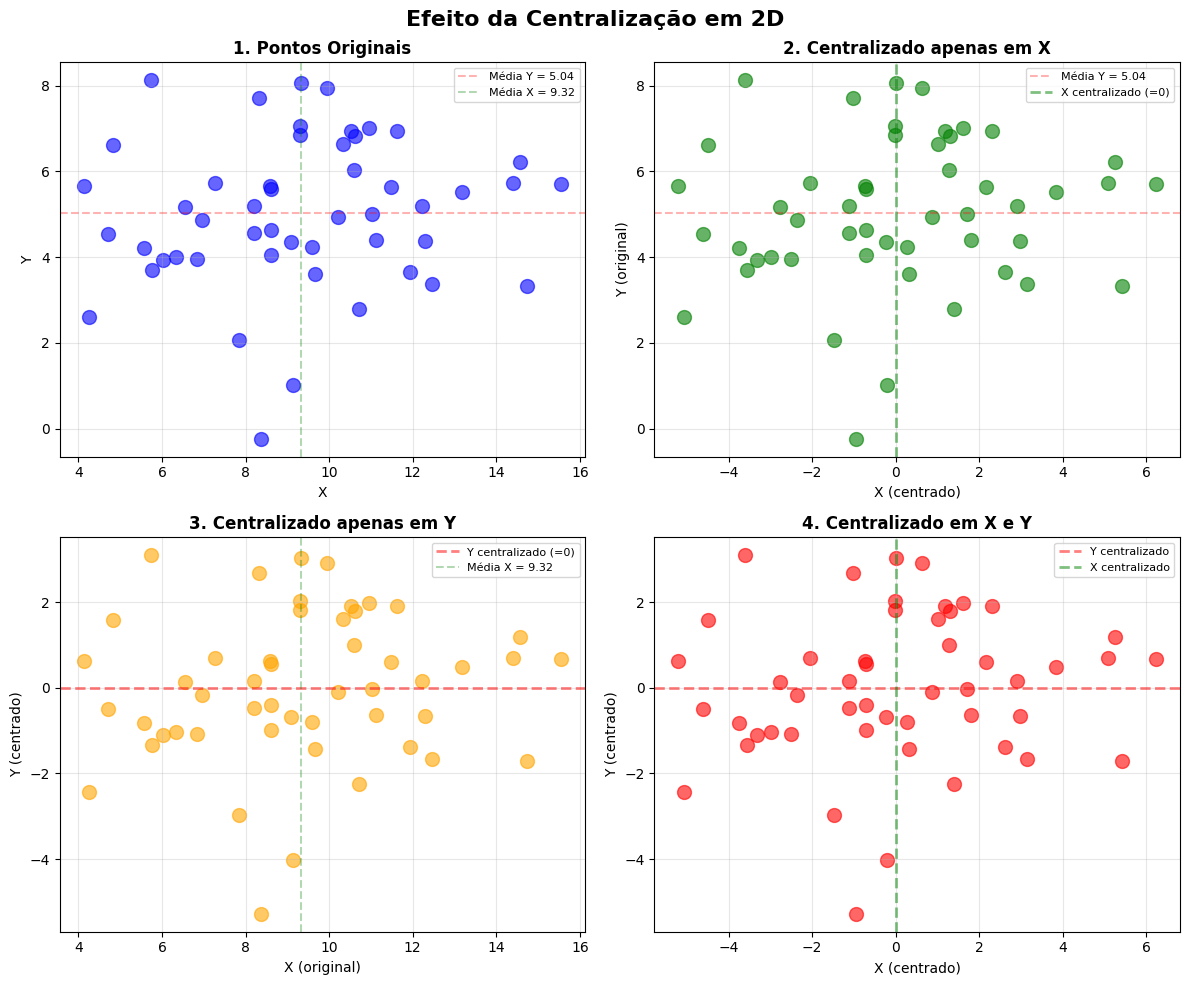

Dados Originais:
  Média de X: 9.3236
  Média de Y: 5.0356
  Desvio padrão de X: 2.7729
  Desvio padrão de Y: 1.7311

Após centralização:
  Média de X (centrado): -0.000000
  Média de Y (centrado): -0.000000
  Desvio padrão de X (centrado): 2.7729
  Desvio padrão de Y (centrado): 1.7311


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# pontos aleatórios
np.random.seed(42)
X = np.random.randn(50) * 3 + 10  # Média ~10, desvio ~3
Y = np.random.randn(50) * 2 + 5   # Média ~5, desvio ~2

# médias
mean_X = X.mean()
mean_Y = Y.mean()

# originais
points_original = (X, Y)

# centralizados apenas em X
X_centered = X - mean_X
points_X_centered = (X_centered, Y)

# centralizados apenas em Y
Y_centered = Y - mean_Y
points_Y_centered = (X, Y_centered)

# centralizados em ambos
points_both_centered = (X_centered, Y_centered)

# figura com 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Efeito da Centralização em 2D', fontsize=16, fontweight='bold')

# Plot 1: Pontos originais
ax = axes[0, 0]
ax.scatter(*points_original, alpha=0.6, s=100, color='blue')
ax.axhline(y=mean_Y, color='r', linestyle='--', alpha=0.3, label=f'Média Y = {mean_Y:.2f}')
ax.axvline(x=mean_X, color='g', linestyle='--', alpha=0.3, label=f'Média X = {mean_X:.2f}')
ax.set_title('1. Pontos Originais', fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Plot 2: Centralizado apenas em X
ax = axes[0, 1]
ax.scatter(*points_X_centered, alpha=0.6, s=100, color='green')
ax.axhline(y=mean_Y, color='r', linestyle='--', alpha=0.3, label=f'Média Y = {mean_Y:.2f}')
ax.axvline(x=0, color='g', linestyle='--', alpha=0.5, linewidth=2, label='X centralizado (=0)')
ax.set_title('2. Centralizado apenas em X', fontweight='bold')
ax.set_xlabel('X (centrado)')
ax.set_ylabel('Y (original)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Plot 3: Centralizado apenas em Y
ax = axes[1, 0]
ax.scatter(*points_Y_centered, alpha=0.6, s=100, color='orange')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=2, label='Y centralizado (=0)')
ax.axvline(x=mean_X, color='g', linestyle='--', alpha=0.3, label=f'Média X = {mean_X:.2f}')
ax.set_title('3. Centralizado apenas em Y', fontweight='bold')
ax.set_xlabel('X (original)')
ax.set_ylabel('Y (centrado)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Plot 4: Centralizado em ambos
ax = axes[1, 1]
ax.scatter(*points_both_centered, alpha=0.6, s=100, color='red')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=2, label='Y centralizado')
ax.axvline(x=0, color='g', linestyle='--', alpha=0.5, linewidth=2, label='X centralizado')
ax.set_title('4. Centralizado em X e Y', fontweight='bold')
ax.set_xlabel('X (centrado)')
ax.set_ylabel('Y (centrado)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Dados Originais:")
print(f"  Média de X: {mean_X:.4f}")
print(f"  Média de Y: {mean_Y:.4f}")
print(f"  Desvio padrão de X: {X.std():.4f}")
print(f"  Desvio padrão de Y: {Y.std():.4f}")
print(f"\nApós centralização:")
print(f"  Média de X (centrado): {X_centered.mean():.6f}")
print(f"  Média de Y (centrado): {Y_centered.mean():.6f}")
print(f"  Desvio padrão de X (centrado): {X_centered.std():.4f}")
print(f"  Desvio padrão de Y (centrado): {Y_centered.std():.4f}")


## Correlacao (Visao Geométrica)

A analise exploratoria também envolve analisar algum tipo de correlacao entre os preditores (Features) e entre os preditores e Variaveis objetivo (target, se existir). Em correlacao linear dizemos que um variavel X é positivamente correlacionada com Y se alto valores de X virem acompanhados de altos valores de Y e Negativamente correlacionada se Altos valores de X vierem com baixos valores de Y ou vice versa. Considere o exemplo em duas variaveis: X:{1,2,3}, Y:{4,5,6} visivelmente podemos ver que tem correlacao linear positiva porem como podemos quantificar isso ? repare que o produto escalar dos dois vetores é 1*4 + 2*5 + 3*6 = 32, porem se somarmos 2 em X temos um novo vetor X':{3,4,5} transladado e um produto escalar maior, mas nao queremos que vetores com valores maiores parecam mais correlacionados. Se centralizarmos os dados (subtrair a media) ambos os vetores central_X:{-1,0,1} e central_X':{-1,0,1} serao iguais, que antes tinham valores de produto escalar diferentes. Agora temos um vetor X' de desvios em relacao a media de X e outro vetor Y' de desvios em relacao a media de Y e ambos saem da origem. Quero agora saber o quao correlacionados eles estao e para isso usamos um conceito já existente que é cosseno entre dois vetores: 

- Cosseno entre dois vetores (Distancia do cosseno):

$$
\cos(\theta) = \frac{x \cdot y}{\|x\| \|y\|}
$$



- Correlacao Linear de Pearson:

$$
\rho_{XY}
=
\frac{
\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{
\sum_{i=1}^{n} (x_i - \bar{x})^2
}
\sqrt{
\sum_{i=1}^{n} (y_i - \bar{y})^2
}
}
$$

Mas ela também pode ser formulada usando covariancia...

$$
\rho_{XY}
=
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X \sigma_Y}
$$

- Covariancia amostral

$$
\operatorname{Cov}(X,Y) =
\frac{1}{n - 1}
\sum_{i=1}^{n}
(x_i - \bar{x})(y_i - \bar{y})
$$

Covariancia é a media dos produtos dos desvios em relacao as medias, ou seja, ela mede se as variacoes de X e Y acontecem na mesma direcao pois se ambos os desvios sao positivos isso aumenta a covariancia, se ambos sao negativos também aumenta a covariancia (-1*-1) mas se os sinais forem opostos quer dizer que estao crescendo em direcoes opostas e portanto reduz a covariancia. Em resumo, ela mede o quanto X e Y crescem na mesma direcao. Tanto a covariância quanto a correlação medem associação linear entre duas variáveis, porem a correlacao é normalizada pelo produto dos desvios padroes que é exatamente a mesma escala do produto dos desvios e faz o valor variar de -1 a 1.

- Matriz de correlacao:

A matriz de correlacao é uma forma de visualizar a correlacao de pearson para todos os pares de variaveis tornando bem pratico e facil a visualizacao.

- Scatterplot: 

Essa tipo de grafico é muito interessante para visualizar rapidamente o tipo de correlacao que os dados tem, principalmente quando nao é linear. 

- Spearman Coefficient: 

O coeficiente linear de pearson é util porem é sensivel a outliers (pois usa media e desvio padrao). Dado esse problema, novos coeficientes robustos foram propostos e spearman é um deles. 

Spearman utiliza exatamente a mesma formula da correlacao de pearson porem nao utilizamos mais os dados brutos (valores reais dos dados) e sims seu rank (rank basicamente é seu indice comecando em 1 quando os dados sao ordenados). Se X:{4,3,1,5}, os valores ordenados sao [1,3,4,5] e portanto os ranks de X sao R(X):{3,2,1,4} cada um representando seu rank na ordenacao crescente e se k numeros sao iguais nos fazemos a media aritmetica do rank deles (exemplo: se tem dois numeros 10 e o rank deles sao respectivamente 3 e 4, entao o rank dos dois numeros será 7/2 = 3,5).

$$
\rho_s = \frac{\operatorname{Cov}(R_X, R_Y)}
{\sigma_{R_X} \sigma_{R_Y}}
$$

Transformamos os dados em ranks e depois utilizamos a mesma formula seguindo a mesma lógica. Spearman é especialmente util quando seus dados possuem outliers ou uma cauda pesada pois ele remove completamente escala dos dados. Util também quando os dados nao sao tao proximos da normal, ou seja, nao linear (diferente de pearson). E quando os dados sao ordinais por natureza pois spearman ira usar bem essa ordem.

- Kendall Coefficient:

Kendall usa uma abordagem Pair-wise em que para cada par de pontos ((xi,yi),(xj,yj)) verificamos se o produto (xi-xj)(yi-yj) é positivo ou negativo. Se for positivo signfica que ou xi < yj e yi < yj ou xi > yj e yi > yj, ou seja, existe uma ordem entre esses pontos e eles sao contabilizados como concordantes. Se negativo significa que ordem deles é discordante. Contabilizamos o numero total de Concordantes C e discordantes D, subtraimos C - D e dividimos pelo total de pares. 

$$
\tau =
\frac{C - D}{\binom{n}{2}}
=
\frac{2(C - D)}{n(n-1)}
$$

Quantos mais discordantes mais proximo de -1 e quanto mais concordantes mais proximo de 1. Podemos interpretar o coeficiente como sendo a P(concordantes) - P(discordante), uma vez que elas sao complementares isso gera em torno de -1 e 1.



Correlação entre X e Y (manual): 1.0
Matriz de Correlação positiva:
      X    Y    Z
X  1.0  1.0  1.0
Y  1.0  1.0  1.0
Z  1.0  1.0  1.0 

Matriz de Correlação negativa:
      X    Y    Z
X  1.0 -1.0 -1.0
Y -1.0  1.0  1.0
Z -1.0  1.0  1.0 

Matriz de Correlação próxima de zero:
           X         Y         Z
X  1.000000  0.238095  0.095238
Y  0.238095  1.000000 -0.761905
Z  0.095238 -0.761905  1.000000 

Matriz de Correlação com dados nao lineares:
           X         Y         Z
X  1.000000  0.447214  0.901146
Y  0.447214  1.000000  0.644808
Z  0.901146  0.644808  1.000000 



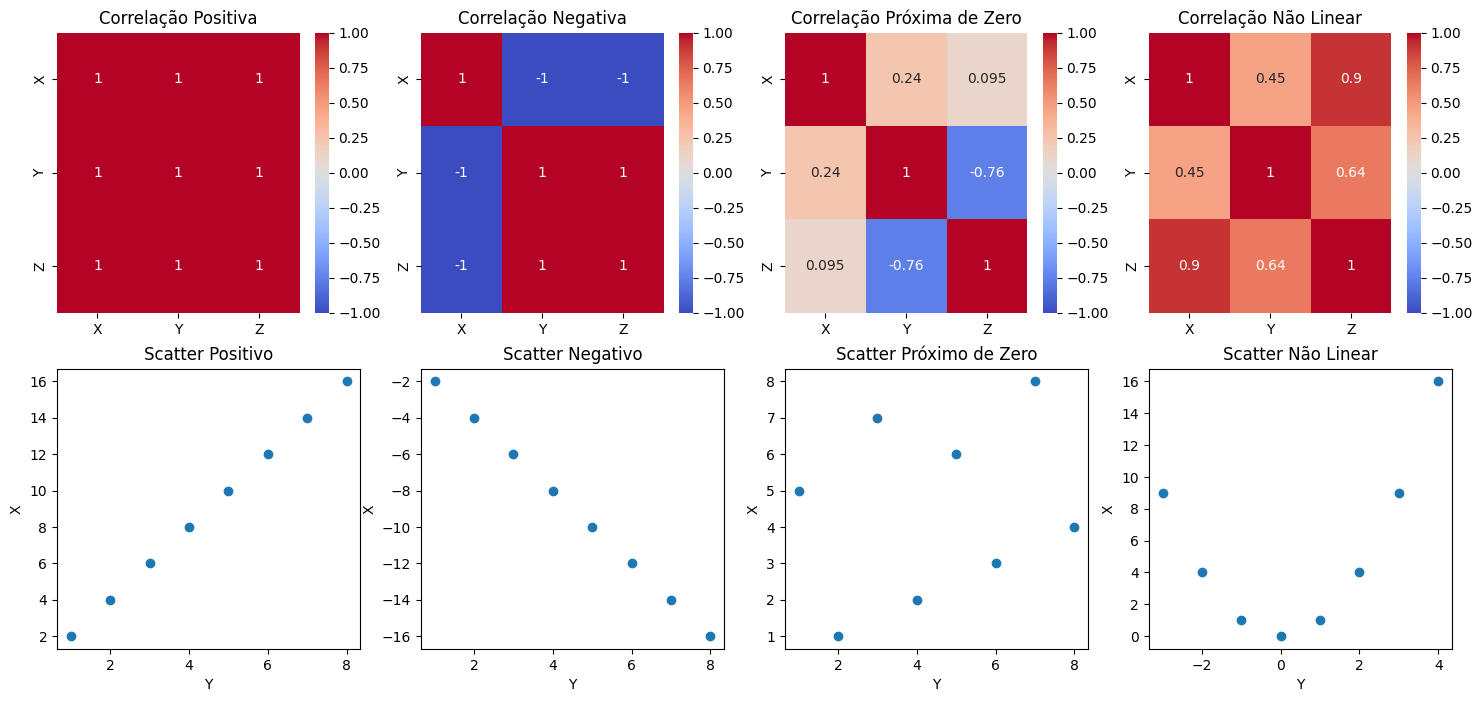

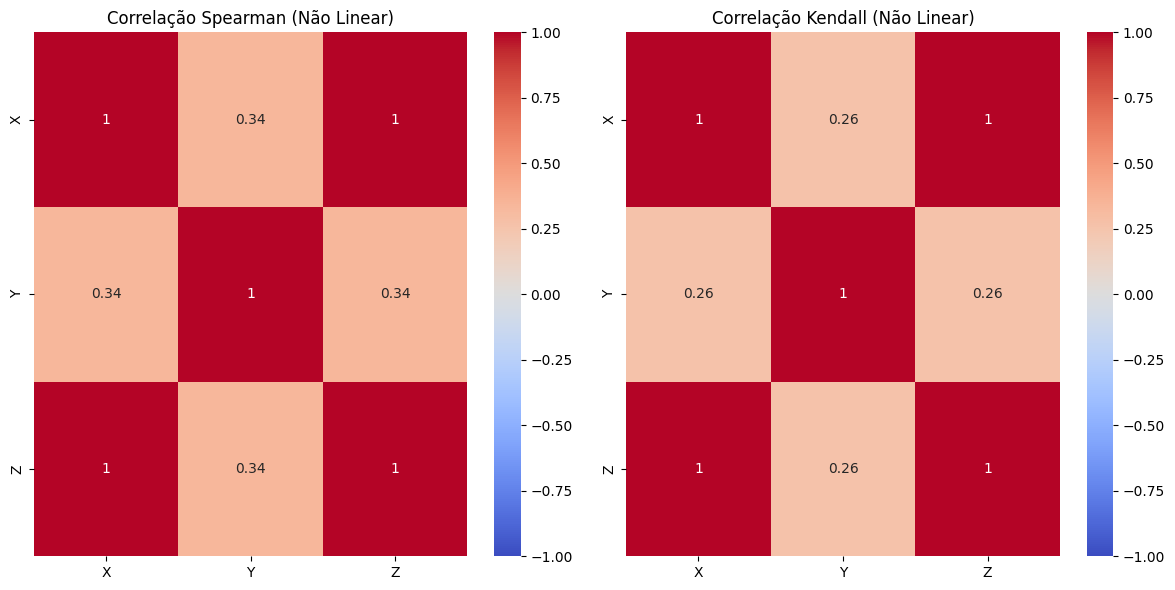

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# positive linear correlation
df_positive = pd.DataFrame({
    "X": [1,2,3,4,5,6,7,8],
    "Y": [2,4,6,8,10,12,14,16],
    "Z": [3,6,9,12,15,18,21,24]
})

# calculo manual da correlacao entre X e Y
mean_X = df_positive["X"].mean()
mean_Y = df_positive["Y"].mean()

numerator = ((df_positive["X"] - mean_X) * (df_positive["Y"] - mean_Y)).sum()
denominator = (
    ((df_positive["X"] - mean_X)**2).sum()**0.5 *
    ((df_positive["Y"] - mean_Y)**2).sum()**0.5
)

correlation_XY = numerator / denominator

print("Correlação entre X e Y (manual):", correlation_XY)

positive_corr = df_positive.corr()
print("Matriz de Correlação positiva:\n", positive_corr, "\n")

# negative linear correlation
df_negative = pd.DataFrame({
    "X": [1,2,3,4,5,6,7,8],
    "Y": [-2,-4,-6,-8,-10,-12,-14,-16],
    "Z": [-1,-2,-3,-4,-5,-6,-7,-8]
})

negative_corr = df_negative.corr()
print("Matriz de Correlação negativa:\n", negative_corr, "\n")

# near zero linear correlation
df_neutral = pd.DataFrame({
    "X": [1,2,3,4,5,6,7,8],
    "Y": [5,1,7,2,6,3,8,4],
    "Z": [2,8,3,6,1,7,4,5]
})

neutral_corr = df_neutral.corr()
print("Matriz de Correlação próxima de zero:\n", neutral_corr, "\n")

# non-linear relationship
df_nonlinear = pd.DataFrame({
    "X": [-3,-2,-1,0,1,2,3,4],
    "Y": [9,4,1,0,1,4,9,16],
    "Z": [-27,-8,-1,0,1,8,27,64]
})

non_linear_corr = df_nonlinear.corr()
print("Matriz de Correlação com dados nao lineares:\n", non_linear_corr, "\n")

# plots
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# heatmaps
sns.heatmap(positive_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[0,0])
axs[0,0].set_title("Correlação Positiva")

sns.heatmap(negative_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[0,1])
axs[0,1].set_title("Correlação Negativa")

sns.heatmap(neutral_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[0,2])
axs[0,2].set_title("Correlação Próxima de Zero")

sns.heatmap(non_linear_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[0,3])
axs[0,3].set_title("Correlação Não Linear")

# scatter plots
axs[1,0].scatter(df_positive["X"], df_positive["Y"])
axs[1,0].set_title("Scatter Positivo")
axs[1,0].set_ylabel("X")
axs[1,0].set_xlabel("Y")

axs[1,1].scatter(df_negative["X"], df_negative["Y"])
axs[1,1].set_title("Scatter Negativo")
axs[1,1].set_ylabel("X")
axs[1,1].set_xlabel("Y")

axs[1,2].scatter(df_neutral["X"], df_neutral["Y"])
axs[1,2].set_title("Scatter Próximo de Zero")
axs[1,2].set_ylabel("X")
axs[1,2].set_xlabel("Y")

axs[1,3].scatter(df_nonlinear["X"], df_nonlinear["Y"])
axs[1,3].set_title("Scatter Não Linear")
axs[1,3].set_ylabel("X")
axs[1,3].set_xlabel("Y")

# heatmaps usando spearman e kendall para os dados nao lineares
spearman_corr = df_nonlinear.corr(method='spearman')
kendall_corr = df_nonlinear.corr(method='kendall')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[0])
axs[0].set_title("Correlação Spearman (Não Linear)")
sns.heatmap(kendall_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axs[1])
axs[1].set_title("Correlação Kendall (Não Linear)")
    

plt.tight_layout()
plt.show()


## Explorando duas variaveis numéricas

- Hexagonal Binning (HexBin), Contours and heatmaps

Scatterplots sao muito uteis para se analisar a distruicao de duas variaveis porém quando a quantidade de dados cresce absurdamente nos datasets o plot se torna muito denso em pontos e todos eles se sobrepondo (overplotting), prejudicando a visualizacao e interpretabilidade. Até menos que 10000 pontos o scatter ainda consegue ser uma boa visualizacao mas apartir disso já é melhor usar outros métodos. Hexbins é baseado em contagem de pontos, alocando os pontos dentro de hexagonais e quanto mais pontos tiverem mais forte é a cor. Contours sao identicos a mapas topograficos mas ao inves de altura mede densidade (usa KDE que aproxima ao continuo).Heatmaps fazem algo proximo do Contours mas usando calor e frio para representar a densidade.


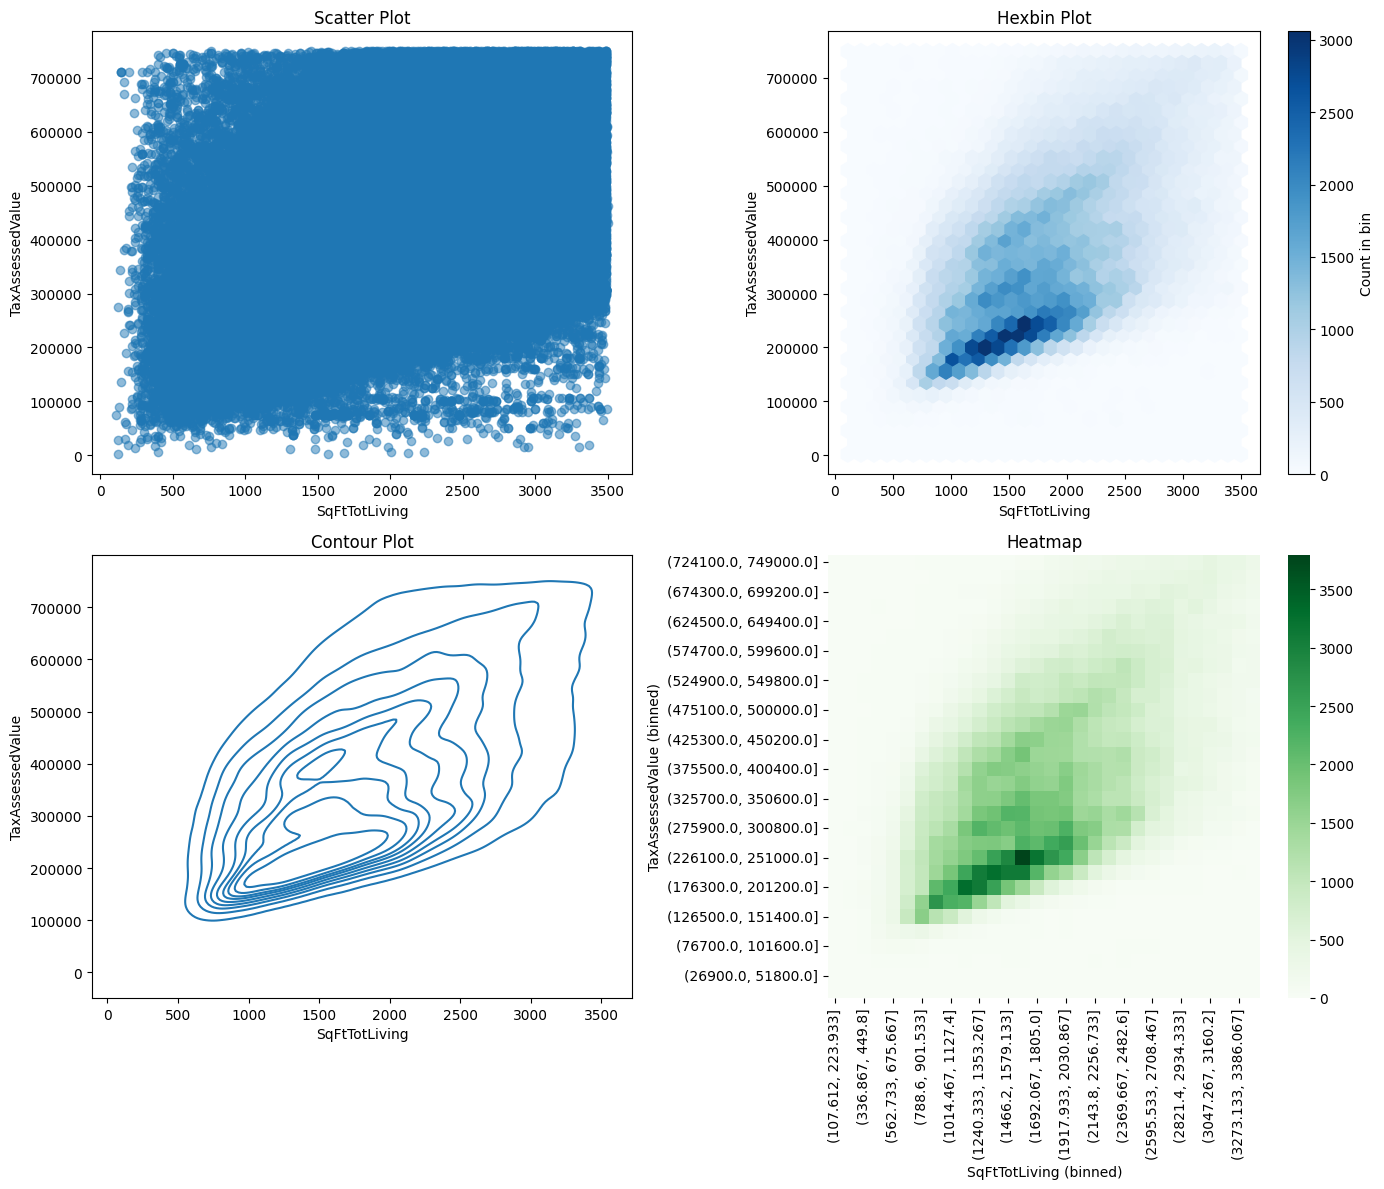

In [12]:
# plotando scatter plot, Hexbin, Contour plot e heatmap para comparar a visualizacao em um dataset grande. 
kc_tax = pd.read_csv("data_statistics/kc_tax.csv")
kc_tax = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) & (kc_tax.SqFtTotLiving > 100) & (kc_tax.SqFtTotLiving < 3500), :] 

# subplot com 2 linhas e 2 colunas 
fig, axs = plt.subplots(2, 2, figsize=(14, 12)) 

# scatter plot
axs[0, 0].scatter(
    kc_tax["SqFtTotLiving"],
    kc_tax["TaxAssessedValue"],
    alpha=0.5
)
axs[0, 0].set_title("Scatter Plot")
axs[0, 0].set_xlabel("SqFtTotLiving")
axs[0, 0].set_ylabel("TaxAssessedValue")


# hexbin plot
hb = axs[0, 1].hexbin(
    kc_tax["SqFtTotLiving"],
    kc_tax["TaxAssessedValue"],
    gridsize=30,
    cmap='Blues'
)
axs[0, 1].set_title("Hexbin Plot")
axs[0, 1].set_xlabel("SqFtTotLiving")
axs[0, 1].set_ylabel("TaxAssessedValue")
fig.colorbar(hb, ax=axs[0, 1], label='Count in bin')


# contour plot
sns.kdeplot(
    x=kc_tax["SqFtTotLiving"],
    y=kc_tax["TaxAssessedValue"],
    ax=axs[1, 0]
)
axs[1, 0].set_title("Contour Plot")
axs[1, 0].set_xlabel("SqFtTotLiving")
axs[1, 0].set_ylabel("TaxAssessedValue")


# heatmap
kc_tax["SqFt_bin"] = pd.cut(kc_tax["SqFtTotLiving"], bins=30)
kc_tax["Tax_bin"] = pd.cut(kc_tax["TaxAssessedValue"], bins=30)

heatmap_data = kc_tax.groupby(["Tax_bin", "SqFt_bin"]).size().unstack(fill_value=0)
heatmap_data = heatmap_data.sort_index(ascending=False)
sns.heatmap(heatmap_data, cmap='Greens', ax=axs[1, 1])
axs[1, 1].set_title("Heatmap")
axs[1, 1].set_xlabel("SqFtTotLiving (binned)")
axs[1, 1].set_ylabel("TaxAssessedValue (binned)")

plt.tight_layout()
plt.show()

## Explorando duas variaveis categóricas

- Tabela de Contingencia:

  A tabela de contingencia de duas variaveis categoricas V1 e V2 é dividida em duas dimensoes. Uma dimensao (linhas) assume todos os valores/classes que a V1 pode assumir (por exemplo, feminino e masculino) e a outra dimensao(colunas) assume todos os valores/classes que V2 pode assumir (por exemplo, jovem, adulto e idoso). O restante da tabela serao valores Cij que sao da classe i de V1 e classe j de V2 (Por exemplo uma mulher que é adulta estaria contabilizada na linha 0 (femino) e na coluna 1 (adulto)). Os valores Cj (colunas) da ultima linha representam o somatório das contagens da classe da coluna j da variavel V2 (por exemplo, a coluna 0 da ultima linha representa o total de instancias que tem classe jovem da variavel V2). Os valores Ci (linhas) da ultima coluna representam a soma das contagens da classe da linha i da variavel V1 (por exemplo, a linha 1 da ultima coluna é o total de instancias com classe masculino da variavel V1).A ultima linha da ultima coluna representa o total geral de instancias (por exemplo, a soma das colunas na ultima linha seriam equivalentes a somar todos os totais das classes de V2 que é igual ao total global e da mesma forma somar todas as linhas da ultima coluna seria equivalente a somar o total de todas as classes de V1 que é o total global também). Esses valores podem ser normalizados (divididos pelos total global) e se tornam fracoes.

  Ela te permite ter uma visao global e divida pelas categorias, sendo muito util para analise exploratória. Além disso, a métrica Qui^2 (qui-quadrado) de Pearson é calculada em cima da tabela de contingencia.

- Qui-quadrado de Pearson (Qui^2):

  $$
  \chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c}
  \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
  $$
  Onde:

  -  O_ij é a frequência observada na célula (i, j) 
  -  E_ij é a frequência esperada sob hipótese de independência
  -  r é o número de linhas
  -  c é o número de colunas


  $$
  E_{ij} =
  \frac{(\text{soma da linha } i)\,(\text{soma da coluna } j)}
  {\text{total geral}}
  $$

  Ou equivalentemente:

  $$
  E_{ij} = \frac{n_{i\cdot} \, n_{\cdot j}}{n}
  $$

  Onde:

  -  n_i é o total da linha i
  -  n_j é o total da coluna j 
  -  n é o total de observações

  Entendendo o valor esperado:

  Primeiramente é importante entender oq é frequencia esperada: é o resultado a probabilidade de um evento multiplicado pelo total. (por exemplo, se a probabilidade de ser homem é 10% entao a frequencia esperada de homens em 100 pessoas é 0.10 * 100 = 10)

  Suponha dados em que globalmente (olhando apenas a variavel PASSOU) 30% das pessoas passaram e 70% das pessoas reprovaram. Agora vamos analisar isso dentro do sexo feminino e masculino: Se a variavel SEXO e PASSOU realmente forem independentes entao a proporcao de mulheres que passaram tem que ser 30% e que nao passaram 70% e nos homens a mesma coisa (ou muito proximas). Se elas forem significativamente diferentes signica que o SEXO e PASSOU nao sao independentes. Essa é a logica do valor esperado de uma linha i e coluna j. Se i e j sao independentes a probabilidade da interssecao é P(i)*P(j) e sabemos que P(i) = n_i/total e P(j) = n_j/total (por exemplo, probabilidade ter passado é 30% e a probabilidade de ser mulher é 20%, ambas sao adquiridas dividindo o total de mulheres (ou aprovados) pelo total de pessoas). Uma vez que temos a probabilidade sob hipotese de independencia podemos ter a frequencia esperada multiplicando a probabilidade pelo total: (total * (n_i/total) * (n_j/total)) = (n_i * n_j / total) que é extamente a formula da frequencia esperada. 


  Qui quadrado mede a associacao entre duas variaveis categoricas e vai de 0 a infinito, quanto maior mais associada. A formula primeiro calcula o erro entre a frequencia Oij observado na tabela e a esperada Eij que é calculado sob hipotese das duas variaveis serem independentes (associacao = 0). 
  Depois esse erro é elevado ao quadrado para dar mais enfase em erros maiores. Esse erro ao quadrado é normalizado dividindo pela esperado e evitando que celulas com muitos valores dominem. Em seguida esse erro é acumulado para todas as linhas e colunas (todos os pares de classes, como (homem,passou), (mulher, passou), (homem, nao passou) e (mulher, nao passou) e temos o qui_quadrado de pearson.

  - Coeficiente de contingencia de pearson:

  $$
  C = \sqrt{
  \frac{\chi^2}{\chi^2 + n}
  }
  $$

  Coeficiente que limita o valor entre 0 e 1.



  




In [13]:
lc_loans = pd.read_csv("data_statistics/lc_loans.csv")

# tabela de contingencia = contagem de cada combinação de categoria (grade e status) em relação ao total de observações.
contingency_table_counts = pd.crosstab(lc_loans["grade"], lc_loans["status"], margins=True)
# tabela normlizada de contingencia = probabilidade conjunta de cada combinação de categoria (grade e status) em relação ao total de observações.
contingency_table_percent = pd.crosstab(lc_loans["grade"], lc_loans["status"], margins=True, normalize='all')

# juntando em uma tabela so para facilitar a visualizacao
contingency_table = pd.concat([contingency_table_counts, contingency_table_percent], axis=1, keys=['Counts', 'Percent'])

contingency_table

Counts                                      Percent            \
status Charged Off Current Fully Paid  Late     All Charged Off   Current   
grade                                                                       
A             1562   50051      20408   469   72490    0.003464  0.110987   
B             5302   93852      31160  2056  132370    0.011757  0.208116   
C             6023   88928      23147  2777  120875    0.013356  0.197197   
D             5007   53281      13681  2308   74277    0.011103  0.118150   
E             2842   24639       5949  1374   34804    0.006302  0.054637   
F             1526    8444       2328   606   12904    0.003384  0.018724   
G              409    1990        643   199    3241    0.000907  0.004413   
All          22671  321185      97316  9789  450961    0.050273  0.712223   

                                       
status Fully Paid      Late       All  
grade                                  
A        0.045254  0.001040  0.160746  
B        0.069097  0.004559  0.293529  
C        0.051328  0.006158  0.268039  
D        0.030337  0.005118  0.164708  
E        0.013192  0.003047  0.077177  
F        0.005162  0.001344  0.028614  
G        0.001426  0.000441  0.007187  
All      0.215797  0.021707  1.000000

In [14]:
# frequencia esperada de grade "C" e status "Late"

total_observacoes = len(lc_loans) # total de observações na tabela
total_grade_C = contingency_table_counts.loc["C", "All"] # total de observações com grade "C" (soma de todas as categorias de status para grade "C")
total_status_late = contingency_table_counts.loc["All", "Late"] # total de observações com status "Late" (soma de todas as categorias de grade para status "Late")
frequencia_esperada = (total_grade_C * total_status_late) / total_observacoes # frequência esperada de observações com grade "C" e status "Late"

erro = contingency_table_counts.loc["C", "Late"] - frequencia_esperada

print(f"Frequência observada: {contingency_table_counts.loc['C', 'Late']}")
print(f"Frequência esperada: {frequencia_esperada:.2f}")
print(f"Erro: {erro:.2f}")

Frequência observada: 2777
Frequência esperada: 2623.83
Erro: 153.17


## Explorando uma variavel numérica em relacao a uma variavel categórica

- Boxplots:

  Uma das formas mais simples de explorar como uma variavel numérica varia de acordo com as categorias de uma variavel categórica é usando Boxplots para cada categoria

  Ele é interessante pois:
  - Mostra os outliers explicitamente
  - Da uma boa ideia de varias estimativas basicas dos dados como (mediana e desvio)
  - Melhor para poucos dados (datasets menores)

  Se a caixa do boxplot é alta quer dizer que os 50% centrais dos dados estao bem dispersos (dados mais espalhados) e se for baixa os dados centrais entao mais concentrados perto da mediana.
  Bigodes sao proporcionais ao IQR mas oq define ele é maior valor dentro do seu intervalo, logo, se ele é longo (proximo do limite do IQR) pode signica que valores altos (ou baixos para o bigode inferior) aconteceram pelo menos uma vez dentro do intervalo do IQR.
  Se a mediana esta deslocada dentro da caixa é provavelmente uma assimetria nos dados centrais. (mediana mais baixa mostra assimetria positiva (direita) e cauda longa a direita e mediana mais alta mostra o contrario)


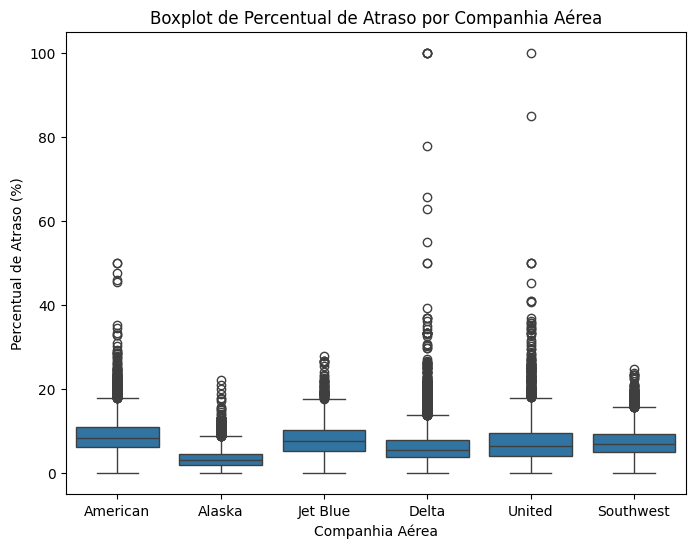

In [15]:
airline_stats = pd.read_csv("data_statistics/airline_stats.csv")

# boxplots por categoria de "airline" para a variável "pct_carrier_delay"
plt.figure(figsize=(8, 6))
sns.boxplot(x="airline", y="pct_carrier_delay", data=airline_stats)
plt.title("Boxplot de Percentual de Atraso por Companhia Aérea")
plt.xlabel("Companhia Aérea")
plt.ylabel("Percentual de Atraso (%)")
plt.show()

# Alaska tem a menor mediana de atraso enquanto american tem a maior mediana de atraso.
# Alaska também tem o menor intervalo interquartil (IQR), indicando menos variabilidade nos atrasos.
# Delta e United tem alguns outliers significativos, sugerindo que há voos com atrasos muito altos nessa companhia.

- Violin Plot:
  Outra forma de se analisar por cada categoria é usando o plot de violino. Que mostra a distribuicao em densidade estimada e espelhada no eixo-y (que lembra um violino). 

  Ele tem algumas vantagens como:
  - Mostrar multimodalidade (varias modas (dois picos))
  - Mostra concentracao de probabilidade local (valores comuns)
  - Mostra assimetria mais claramente (facil de interpretar)
  - Com muitos dados ela fica mais proxima da real (uma aproximacao) -> ideal para muitos dados


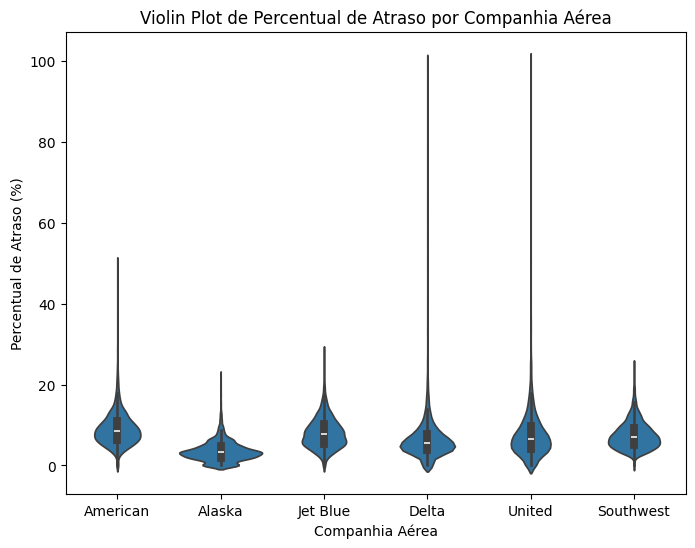

In [16]:
# violin plot por categoria de "airline" para a variável "pct_carrier_delay"
plt.figure(figsize=(8, 6))
sns.violinplot(x="airline", y="pct_carrier_delay", data=airline_stats)
plt.title("Violin Plot de Percentual de Atraso por Companhia Aérea")
plt.xlabel("Companhia Aérea")
plt.ylabel("Percentual de Atraso (%)")
plt.show()

# Com o violin plot, podemos observar a distribuição completa dos dados de atraso para cada companhia aérea.
# E fica claro que para alaska grande parte da probabilidade de atraso está concentrada em valores baixos e próximos de zero.


# Observando mais que duas variaveis:

- Condicionamento de variavel: 

Na imagem de impostos x metro quadrado construido podemos identificar varios clusteres como valores bem diferentes entre si e talvez tenham sido afetados por outra variavel. Os dados tem 3 variaveis importantes e a ultima é a localizacao (zipcode). Para visualizar isso podemos fixar varios zip codes e plotar os impostos x metro quadrado construido e assim observar varias facetas dos dados. 

- Facets plot:

Consiste na plotagem do mesmo grafico varias vezes mas em cada uma filtrando por uma variavel com valor fixado (por exemplo, quero apenas casas que tem zip code xxxxx).

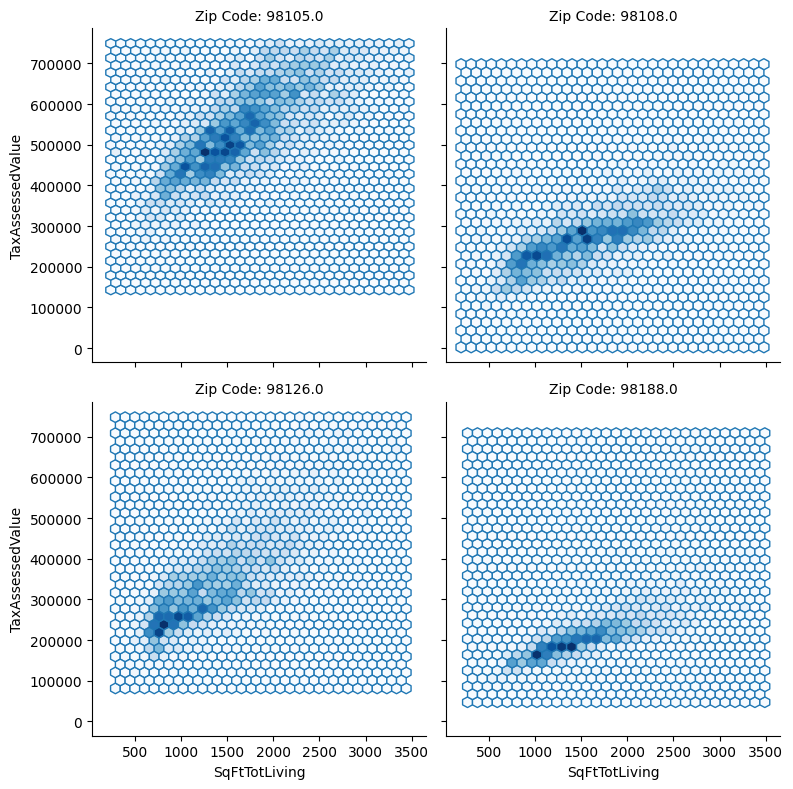

In [17]:
# hexbin facetado por zip code 

zip_codes = [98188, 98105, 98108, 98126] # alguns zip codes de exemplo
kc_tax_subset = kc_tax[kc_tax["ZipCode"].isin(zip_codes)] # filtrando o dataset para conter apenas os zip codes selecionados

g = sns.FacetGrid(kc_tax_subset, col="ZipCode", col_wrap=2, height=4) # criando um grid de facetas (subplots) baseado na coluna "ZipCode", com 2 colunas por linha e altura de 4 para cada subplot
g.map_dataframe(plt.hexbin, x="SqFtTotLiving", y="TaxAssessedValue", gridsize=30, cmap='Blues')
g.set_axis_labels("SqFtTotLiving", "TaxAssessedValue")
g.set_titles("Zip Code: {col_name}")
plt.tight_layout()
plt.show()
